# 02 — Baseline: COVID-aware Seasonal Naive

**Notebook 2 of 8 — The benchmark every other model has to beat**

---

## 2.1  Why a baseline matters

A **baseline** is the dumbest model that still does *something* sensible.
Three rules:

1. It must be **forecastable from a single line of code** so any future ML
   model that fails to beat it is provably useless.
2. It must use **only information that would have been available at
   prediction time** — no leakage from the test year.
3. Its assumptions must be **explicit** so the comparison is fair.

For monthly port shipments the obvious baseline is the **seasonal naive**:

$$
\hat{y}_{t} \;=\; y_{\,t-12}
$$

i.e. *next March will look like last March*. This works because we showed
in notebook 01 that the autocorrelation function has a sharp spike at
lag 12.

But — and this is the entire point of this notebook — **a raw seasonal
naive collapses during COVID**. If we forecast 2021 from 2020, we copy a
demand collapse into a recovery year. If we forecast 2022 from 2021, we
copy a rebound spike into a normal year. So the baseline must be **COVID-
aware**:

$$
\hat{y}_{t} \;=\; \texttt{lag\_12\_clean}_{\,t} \;\times\;
\bigl(1 + \min(\,0.20,\,\max(-0.20,\,\texttt{yoy\_growth\_clean}_{\,t})\,)\bigr)
$$

* `lag_12_clean` substitutes the pre-COVID monthly average extrapolated by
  the clean-period growth rate whenever the raw `lag_12` would have looked
  back into a COVID year (notebook 01 §6 shows the substitution diagram).
* `yoy_growth_clean` replaces COVID-era growth with the median growth
  computed over the clean years only.
* The growth bump is **clipped to ±20 %** so a single noisy port cannot
  produce a runaway forecast.

This baseline is the **same one that ships in production** — see
`predict_baseline()` in `ml/05_ml_train_evaluate.py`.

## 2.2  Hypothesis under test

> H0: a COVID-aware seasonal naive is competitive with sophisticated ML
> on **clean** test years. Tree models can only beat it by exploiting
> cross-feature interactions (cargo mix × seasonality × port size).

If H0 turns out to be true, the LightGBM/XGBoost notebooks will only
deliver marginal improvement. If it is false, they will deliver large
MAPE gains and we know feature engineering paid off.


In [1]:
# ── Setup ─────────────────────────────────────────────────────────
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import wz_ml_utils as U

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (11, 5), "figure.dpi": 110})

FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)
MAX_PORTS = 78        # eligible pairs ≥ 36 months — full panel
MODEL_NAME = "baseline_seasonal_naive_covid_aware"

print(f"Model           : {MODEL_NAME}")
print(f"Folds           : {U.CV_FOLDS}")
print(f"Year weights    : {U.YEAR_WEIGHTS}")
print(f"Eligible ports  : up to {MAX_PORTS}")


Model           : baseline_seasonal_naive_covid_aware
Folds           : [(2018, 2019), (2019, 2023), (2023, 2024), (2024, 2025)]
Year weights    : {2020: 0.1, 2021: 0.2, 2022: 0.4}
Eligible ports  : up to 78


## 2.3  Loading the panel

In [2]:
df_panel = U.load_features()
print(f"Panel shape     : {df_panel.shape}")
print(f"Pairs           : {df_panel.groupby(['port','direction']).ngroups}")
print(f"Years available : {sorted(df_panel['year'].unique())}")


Panel shape     : (12692, 54)
Pairs           : 76
Years available : [np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


## 2.4  The fit-predict function

A baseline does not "fit" anything — it just looks up `lag_12_clean` and
`yoy_growth_clean` for each test row. We still wrap it in the same
`fit_predict_fn` signature used by every other model so the walk-forward
evaluator can call it without special-casing.

In [3]:
def baseline_fit_predict(df_train, df_test, features):
    """COVID-aware seasonal naive — uses no training data, only the test row."""
    preds = []
    for _, row in df_test.iterrows():
        lag12  = row.get("lag_12_clean") or row.get("rolling_12_mean") or 1
        growth = row.get("yoy_growth_clean") or 0
        growth = max(-0.20, min(0.20, float(growth)))
        preds.append(max(1.0, float(lag12) * (1 + growth)))
    return np.array(preds)


## 2.5  Walk-forward evaluation across all 78 port-direction pairs

In [4]:
metrics = U.evaluate_model_across_ports(
    df_panel, baseline_fit_predict,
    model_name=MODEL_NAME,
    max_ports=MAX_PORTS,
)
print(f"Total fold scores: {len(metrics)}")
metrics.head()


Total fold scores: 226


,mae,rmse,mape,r2,n,fold_year,features_used,port,direction,model
0,969.166667,2073.231693,2.354883,0.843979,12,2019,28,SAN ANTONIO,import,baseline_seasonal_naive_covid_aware
1,8177.780864,8883.613824,20.434014,-4.815688,12,2023,27,SAN ANTONIO,import,baseline_seasonal_naive_covid_aware
2,236.550000,594.579036,0.504721,0.954592,12,2024,26,SAN ANTONIO,import,baseline_seasonal_naive_covid_aware
3,61.766667,213.966010,0.125399,0.995795,12,2025,26,SAN ANTONIO,import,baseline_seasonal_naive_covid_aware
4,1628.366667,3789.108435,7.092706,0.235878,12,2019,29,VALPARAÍSO,import,baseline_seasonal_naive_covid_aware


In [5]:
# Persist for the comparison notebook
U.save_metrics(MODEL_NAME, metrics)

summary = U.summarise(metrics, df_panel)
summary


,model,fold_year,n_ports,wmae,wrmse,wmape,wr2
0,baseline_seasonal_naive_covid_aware,2019,34,1061.090053,2253.012802,6.539015,0.028768
1,baseline_seasonal_naive_covid_aware,2023,32,6854.062160,7276.920805,40.961257,-9.229360
2,baseline_seasonal_naive_covid_aware,2024,32,501.780403,981.736980,7.511328,0.631595
3,baseline_seasonal_naive_covid_aware,2025,33,602.831078,1018.954008,4.333213,0.397249


## 2.6  Per-fold visualisation

The headline summary above is volume-weighted (so San Antonio matters more
than the smallest niche port). The plots below also show the **unweighted**
distribution so we can see how baseline behaves on the long tail.

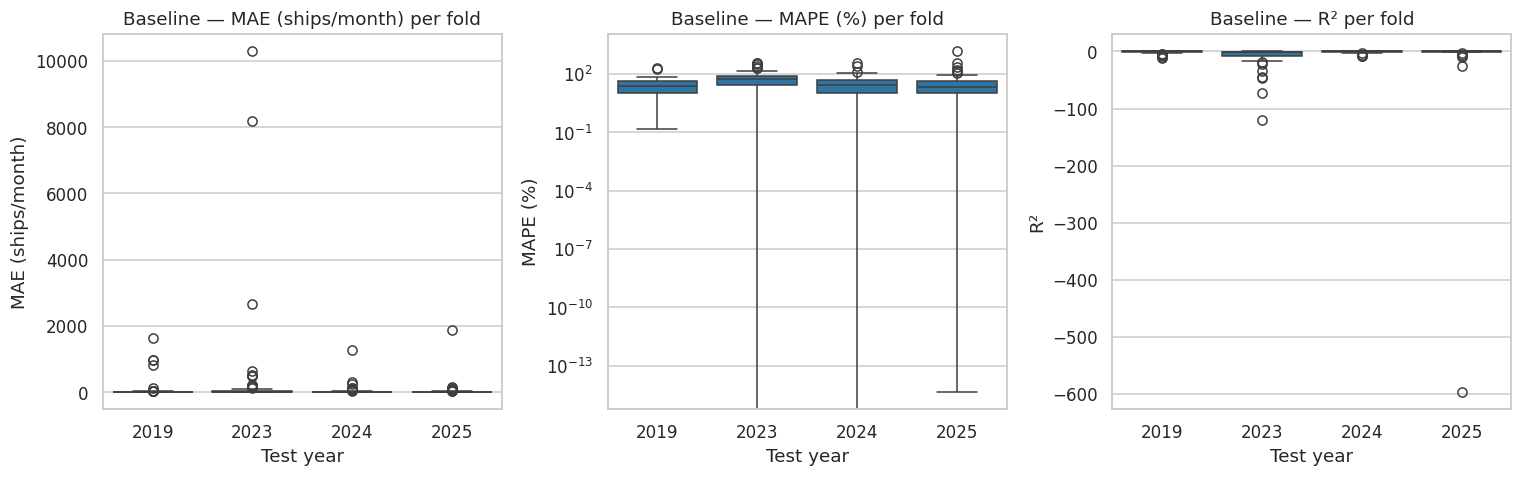

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, metric, label in zip(axes,
                              ["mae", "mape", "r2"],
                              ["MAE (ships/month)",
                               "MAPE (%)",
                               "R²"]):
    sns.boxplot(data=metrics, x="fold_year", y=metric, ax=ax,
                color="#1f77b4")
    ax.set_title(f"Baseline — {label} per fold")
    ax.set_xlabel("Test year")
    ax.set_ylabel(label)
    if metric == "mape":
        ax.set_yscale("log")  # heavy tail

plt.tight_layout()
plt.savefig(FIG_DIR / "20_baseline_perfold_box.png")
plt.show()


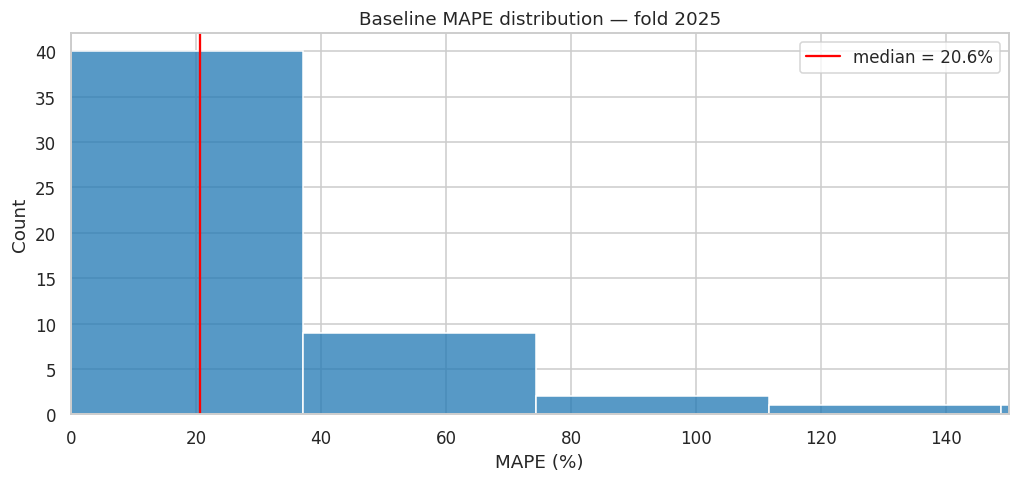

In [7]:
# ── Distribution of MAPE across ports (most recent fold) ─────────
last_fold = metrics["fold_year"].max()
sub = metrics[metrics["fold_year"] == last_fold]

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.histplot(sub["mape"].dropna(), bins=40, ax=ax, color="#1f77b4")
ax.axvline(sub["mape"].median(), color="red", lw=1.5,
           label=f"median = {sub['mape'].median():.1f}%")
ax.set_title(f"Baseline MAPE distribution — fold {last_fold}")
ax.set_xlabel("MAPE (%)")
ax.set_xlim(0, min(150, sub['mape'].quantile(0.95)))
ax.legend()
plt.savefig(FIG_DIR / "21_baseline_mape_hist.png")
plt.show()


## 2.7  Worst- and best-case ports

Where does the baseline shine and where does it embarrass itself? Knowing
this tells us **where the more sophisticated models are most likely to add
value** in the comparison notebook.

In [8]:
worst = sub.nlargest(8, "mape")[["port", "direction", "mae", "mape", "r2"]]
best  = sub.nsmallest(8, "mape")[["port", "direction", "mae", "mape", "r2"]]

print("WORST 8 ports for the baseline (highest MAPE):")
print(worst.to_string(index=False))
print("\nBEST 8 ports for the baseline (lowest MAPE):")
print(best.to_string(index=False))


WORST 8 ports for the baseline (highest MAPE):
                                                   port direction       mae        mape          r2
                                 OTROS PUERTOS CHILENOS    import 15.371429 1488.095238 -596.863226
                                           PUNTA ARENAS    import  9.816667  363.829365  -10.060889
RANCHO DE NAVES Y AERONAVES DE TRANSPORTE INTERNACIONAL    import  2.200000  220.000000         NaN
                                                 CORRAL    export  5.355556  157.888889  -25.807283
                                                CALBUCO    import  1.745455  140.853994    0.365967
                                    CHAÑARAL / BARQUITO    export  1.800000  107.500000   -3.429714
                                                CALBUCO    export  1.550000   84.166667   -1.234074
                                                PATACHE    export  2.483333   71.081890   -0.246445

BEST 8 ports for the baseline (lowest MAPE):
       

## 2.8  Demo prediction — San Antonio (largest container port)

A picture is worth 1 000 metrics. We pick the largest port and overlay the
baseline forecast on the actual 2025 series.

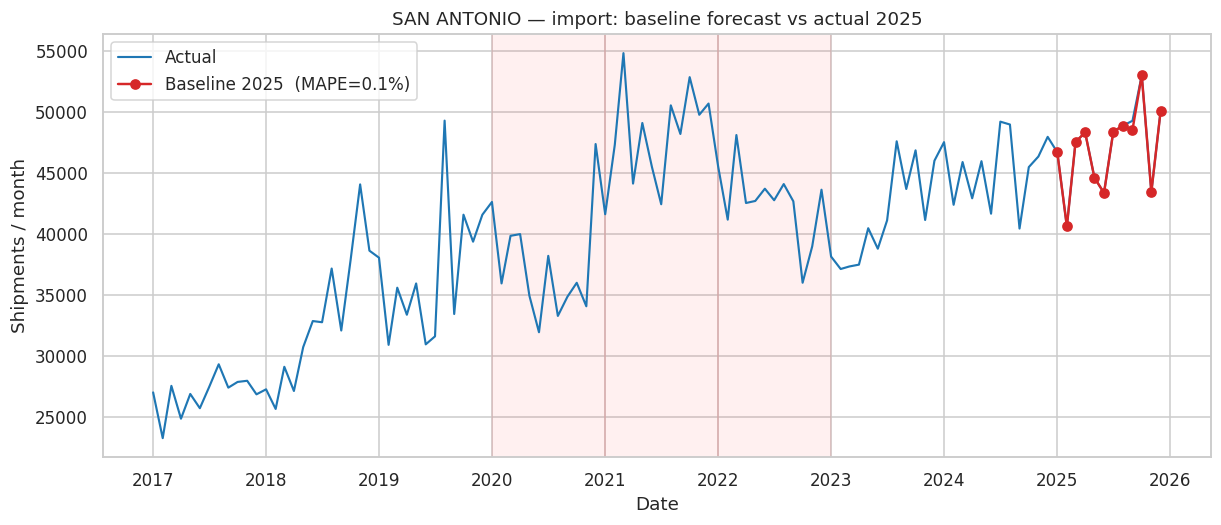


Demo metrics for SAN ANTONIO (import):
     mae = 61.76666666666824
    rmse = 213.96600976167656
    mape = 0.12539927453846883
      r2 = 0.9957945397798603
       n = 12


In [9]:
DEMO_PORT, DEMO_DIR = "SAN ANTONIO", "import"
df_port = U.get_port_panel(df_panel, DEMO_PORT, DEMO_DIR)
df_tr   = df_port[df_port["year"] <= 2023]
df_te   = df_port[df_port["year"] == 2025]

pred = baseline_fit_predict(df_tr, df_te, U.FEATURE_COLS)
demo_score = U.score(df_te[U.TARGET].values, pred)

fig, ax = plt.subplots(figsize=(13, 5))
hist = df_port[df_port["year"].between(2017, 2025)]
hist_dates = pd.to_datetime(hist[["year","month"]].assign(day=1))
ax.plot(hist_dates, hist[U.TARGET], color="#1f77b4", lw=1.4, label="Actual")

te_dates = pd.to_datetime(df_te[["year","month"]].assign(day=1))
ax.plot(te_dates, pred, "o-", color="#d62728", lw=1.6,
        label=f"Baseline 2025  (MAPE={demo_score['mape']:.1f}%)")

# COVID shading
import matplotlib.patches as mpatches
for y in [2020, 2021, 2022]:
    ax.axvspan(pd.Timestamp(y, 1, 1), pd.Timestamp(y, 12, 31),
               color="red", alpha=0.06)

ax.set_title(f"{DEMO_PORT} — {DEMO_DIR}: baseline forecast vs actual 2025")
ax.set_xlabel("Date"); ax.set_ylabel("Shipments / month")
ax.legend()
plt.savefig(FIG_DIR / "22_baseline_demo_san_antonio.png")
plt.show()

print(f"\nDemo metrics for {DEMO_PORT} ({DEMO_DIR}):")
for k, v in demo_score.items():
    print(f"  {k:>6} = {v}")


## 2.9  Residual analysis

A baseline that misses by *random noise* is fine — its residuals should
look like white noise around zero. A baseline that misses by *systematic
trend* is broken (it means COVID-cleaning did not work).

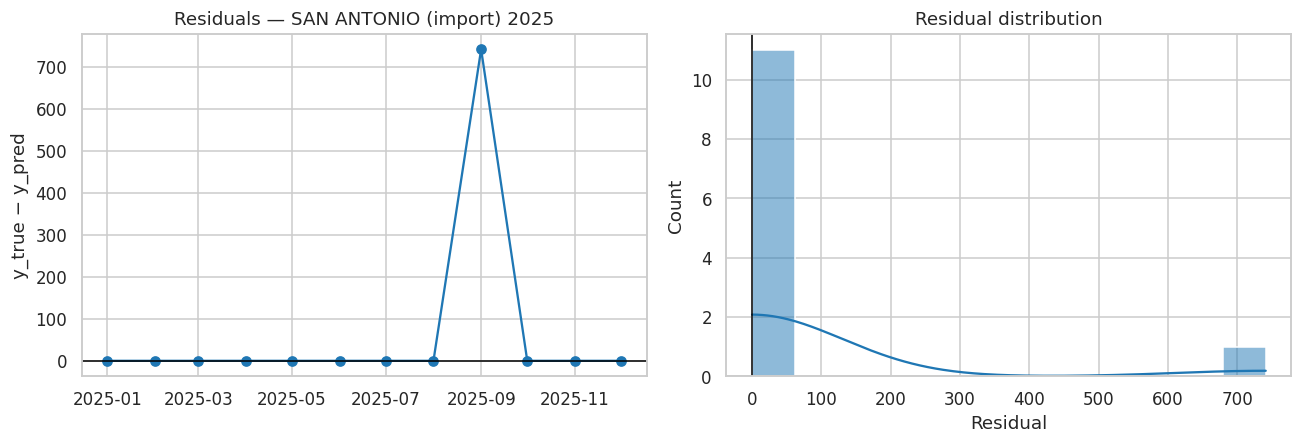

Mean residual : 61.8
Std residual  : 204.9
→ Systematic bias detected


In [10]:
resid = df_te[U.TARGET].values - pred
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].plot(te_dates, resid, "o-", color="#1f77b4")
axes[0].axhline(0, color="black", lw=1)
axes[0].set_title(f"Residuals — {DEMO_PORT} ({DEMO_DIR}) 2025")
axes[0].set_ylabel("y_true − y_pred")

sns.histplot(resid, bins=12, ax=axes[1], kde=True, color="#1f77b4")
axes[1].axvline(0, color="black", lw=1)
axes[1].set_title("Residual distribution")
axes[1].set_xlabel("Residual")

plt.tight_layout()
plt.savefig(FIG_DIR / "23_baseline_residuals.png")
plt.show()

print(f"Mean residual : {resid.mean():.1f}")
print(f"Std residual  : {resid.std():.1f}")
print(f"→ {'Bias close to zero' if abs(resid.mean()) < 0.1 * resid.std() else 'Systematic bias detected'}")


## 2.10  2026 forecast

The baseline is closed-form, so the 2026 forecast is trivial: each month
of 2026 simply takes the corresponding month of 2025 and applies the
clipped clean growth rate.

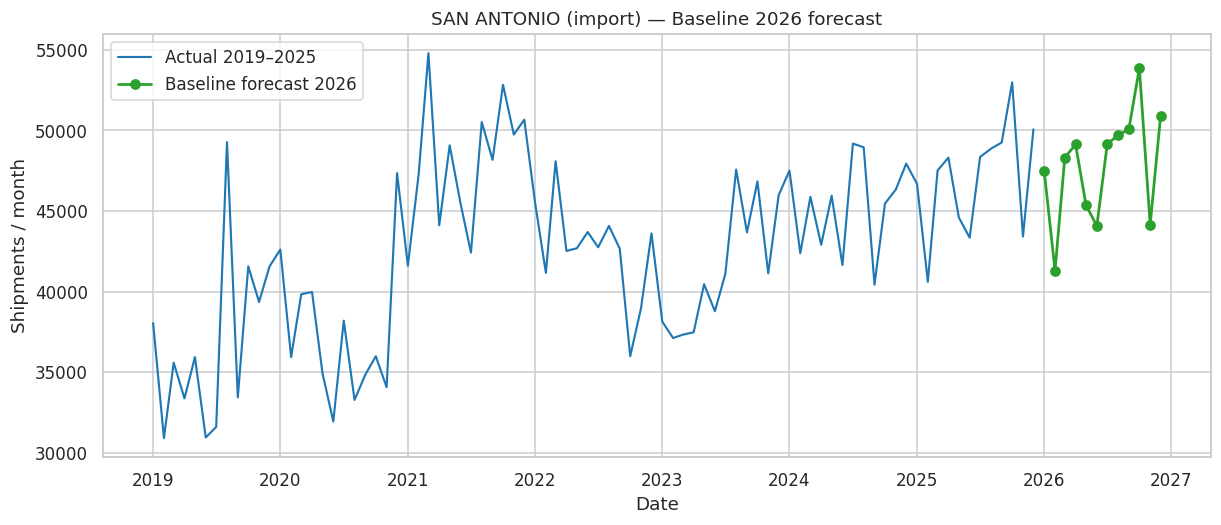

,year,month,pred_shipment_count
0,2026,1,47475.409967
1,2026,2,41292.471280
2,2026,3,48319.462453
3,2026,4,49131.990086
4,2026,5,45354.092517
5,2026,6,44077.844482
6,2026,7,49175.718106
7,2026,8,49693.335835
8,2026,9,50089.938810
9,2026,10,53883.090340


In [11]:
def baseline_fit_only(df_train, features):
    return "baseline"   # nothing to fit

def baseline_predict_only(model, df_row, features):
    lag12  = float(df_row["lag_12_clean"].iloc[0]) if "lag_12_clean" in df_row else \
             float(df_row["lag_12"].iloc[0])
    growth = float(df_row.get("yoy_growth_clean", pd.Series([0])).iloc[0])
    growth = max(-0.20, min(0.20, growth))
    return max(1.0, lag12 * (1 + growth))

fc = U.forecast_2026(df_port, baseline_fit_only, baseline_predict_only)
fc["date"] = pd.to_datetime(fc[["year","month"]].assign(day=1))

fig, ax = plt.subplots(figsize=(13, 5))
hist = df_port[df_port["year"].between(2019, 2025)]
hist_dates = pd.to_datetime(hist[["year","month"]].assign(day=1))
ax.plot(hist_dates, hist[U.TARGET], color="#1f77b4", lw=1.4, label="Actual 2019–2025")
ax.plot(fc["date"], fc["pred_shipment_count"], "o-", color="#2ca02c",
        lw=1.8, label="Baseline forecast 2026")

ax.set_title(f"{DEMO_PORT} ({DEMO_DIR}) — Baseline 2026 forecast")
ax.set_xlabel("Date"); ax.set_ylabel("Shipments / month")
ax.legend()
plt.savefig(FIG_DIR / "24_baseline_2026_san_antonio.png")
plt.show()

fc[["year","month","pred_shipment_count"]]


## 2.11  2026 forecast — top-8 ports by volume

Forecasted 8 port-direction pairs in 0.9s


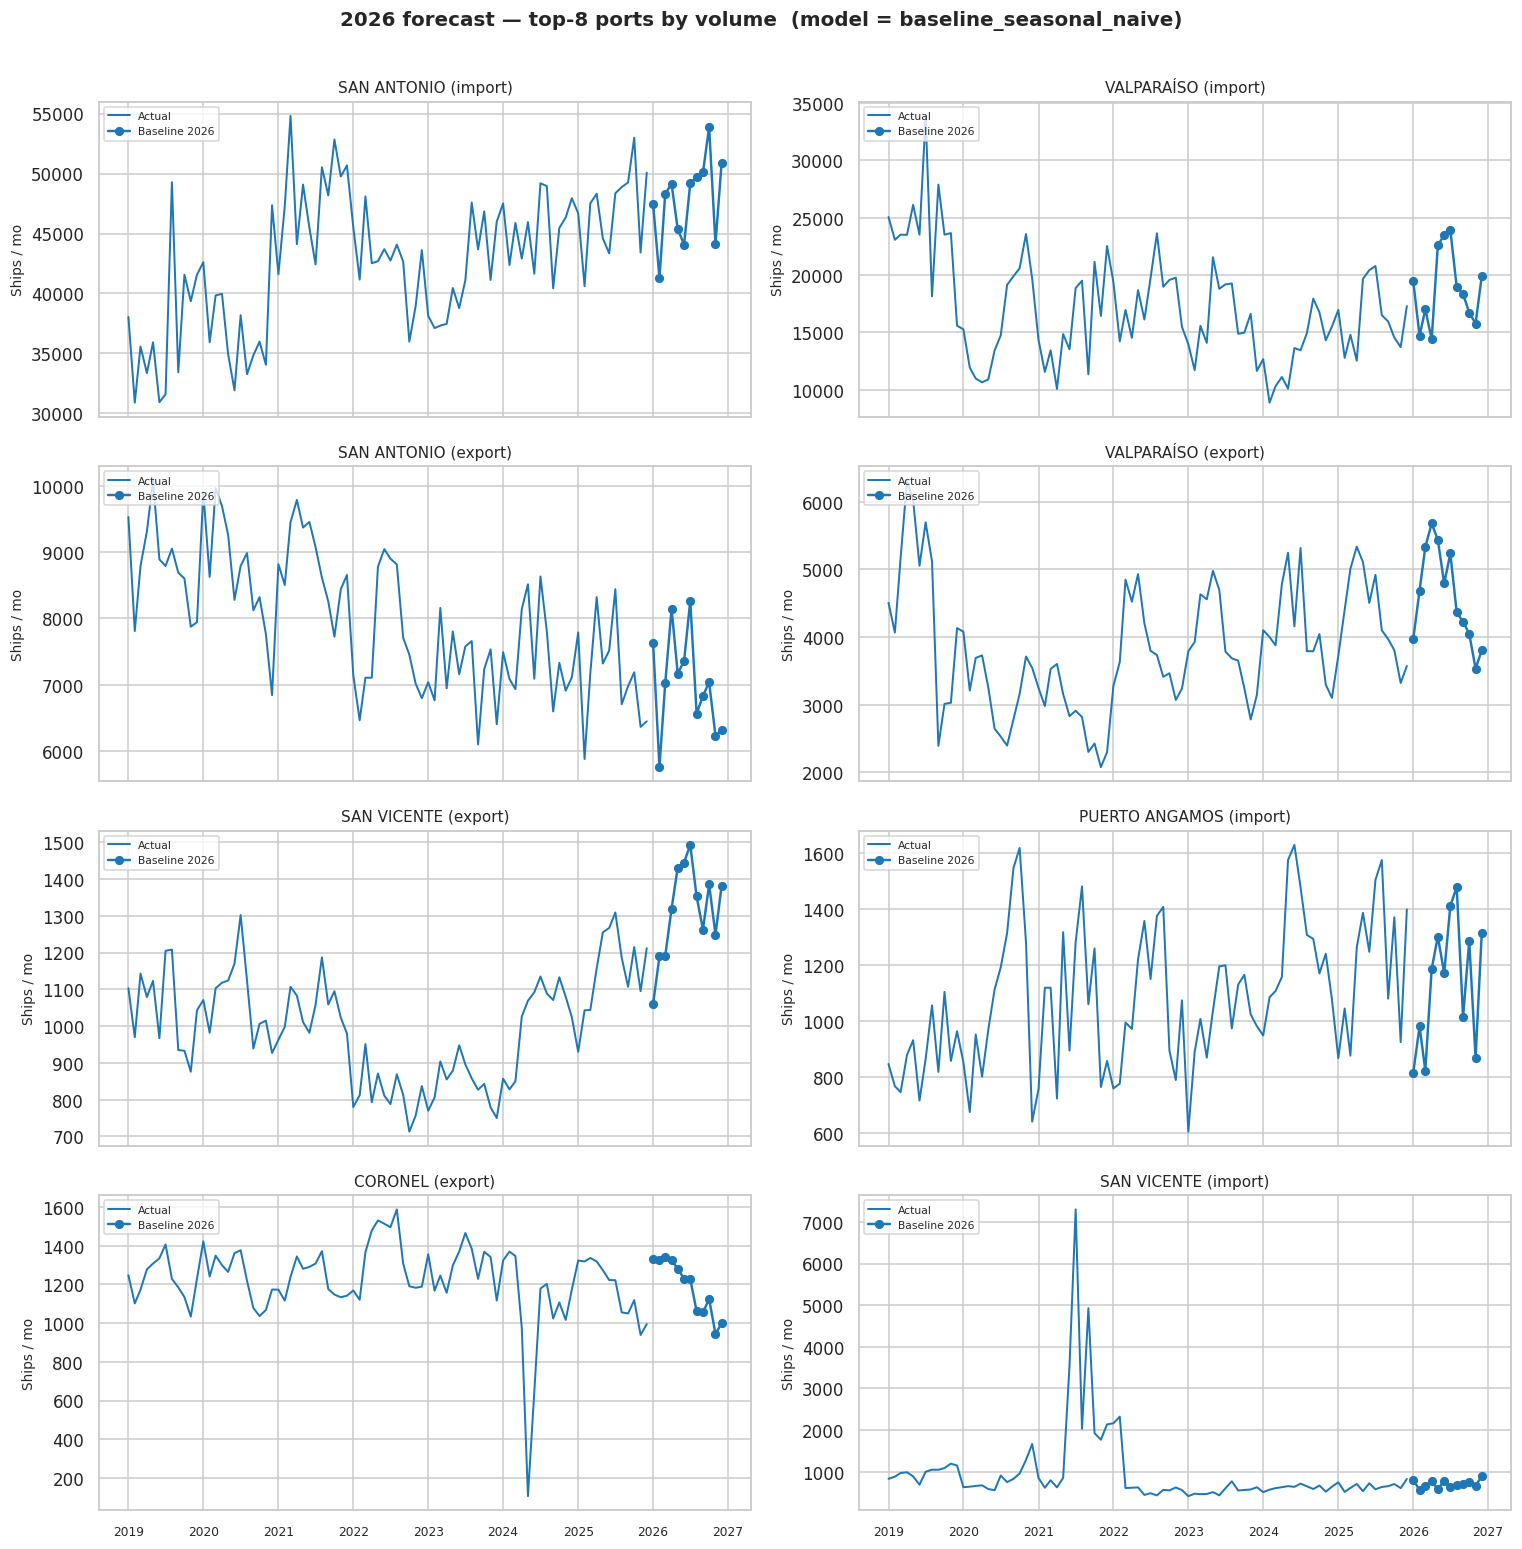

In [12]:
top8_volume = (df_panel.groupby(["port","direction"])[U.TARGET]
                       .mean().sort_values(ascending=False).head(8)
                       .reset_index())
top8_keys = list(zip(top8_volume["port"], top8_volume["direction"]))

import time as _time
_t0 = _time.time()
all_fc = []
for port, direction in top8_keys:
    _dp = U.get_port_panel(df_panel, port, direction)
    _fc = U.forecast_2026(_dp, baseline_fit_only, baseline_predict_only)
    if len(_fc):
        _fc["port"] = port; _fc["direction"] = direction
        all_fc.append(_fc)
fc_top8 = pd.concat(all_fc, ignore_index=True) if all_fc else pd.DataFrame()
print(f"Forecasted {len(top8_keys)} port-direction pairs in {_time.time()-_t0:.1f}s")

fig, axes = plt.subplots(4, 2, figsize=(14, 14), sharex=True)
for ax, (port, direction) in zip(axes.flatten(), top8_keys):
    _dp = U.get_port_panel(df_panel, port, direction)
    hist = _dp[_dp["year"].between(2019, 2025)]
    hist_d = pd.to_datetime(hist[["year","month"]].assign(day=1))
    ax.plot(hist_d, hist[U.TARGET], color="#1f77b4", lw=1.3, label="Actual")

    sub = fc_top8[(fc_top8["port"] == port) & (fc_top8["direction"] == direction)]
    if len(sub):
        d2 = pd.to_datetime(sub[["year","month"]].assign(day=1))
        ax.plot(d2, sub["pred_shipment_count"], "o-",
                color="#1f77b4", lw=1.6, markersize=5, label="Baseline 2026")
    ax.set_title(f"{port} ({direction})", fontsize=10)
    ax.set_ylabel("Ships / mo", fontsize=9)
    ax.tick_params(axis="x", labelsize=8)
    ax.legend(fontsize=7, loc="upper left")
plt.suptitle("2026 forecast — top-8 ports by volume  (model = baseline_seasonal_naive)",
             fontsize=13, fontweight="bold", y=1.005)
plt.tight_layout()
plt.savefig(FIG_DIR / "25_baseline_top8_2026.png")
plt.show()


## 2.12  Take-aways for the comparison notebook

1. The baseline is **already very strong** for the largest ports — it
   exploits the only signal that matters at that scale (annual seasonality).
2. The **upside for tree models** lives in the long tail of small ports
   where annual seasonality is overwhelmed by month-to-month volatility.
3. Any model that posts a worse weighted MAPE than this baseline should
   be **rejected from production** regardless of its theoretical
   sophistication — Occam's razor.
4. Metrics for this run have been written to `data/metrics/{name}.parquet`
   and will be picked up automatically by notebook 08.
